# Confidence Intervals for Accuracy

This tutorial uses synthetic **Project Frog** evaluation results to answer a practical question: when should an engineer trust an observed accuracy metric?

We focus on a fixed expected accuracy of **0.85** and vary sample size to show two ideas:

1. A smaller sample lowers confidence in the estimate.
2. A smaller sample does **not** automatically lower the true accuracy.

## Why does an AI engineer need to understand this?

Release dashboards often report a single number such as accuracy = 0.84. Without uncertainty, that number can be misleading. In Project Frog, engineers need to know whether a metric moved because the system changed or because the sample is too small to pin performance down precisely.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from applied_stats_ai import bootstrap_metric, clopper_pearson_interval, wilson_interval

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(7)
accuracy = 0.85
sample_sizes = [20, 50, 100, 500, 1000]

## Accuracy as a binomial proportion

If each Project Frog evaluation outcome is marked correct or incorrect, then observed accuracy is the proportion of successes in a binomial-style sample. That gives us a simple way to reason about standard error and interval estimates.

In [2]:
outcomes = {n: rng.binomial(1, accuracy, size=n) for n in sample_sizes}

summary_rows = []
for n, values in outcomes.items():
    successes = int(values.sum())
    observed_accuracy = successes / n
    standard_error = math.sqrt(observed_accuracy * (1 - observed_accuracy) / n)
    wilson = wilson_interval(successes, n)
    exact = clopper_pearson_interval(successes, n)
    summary_rows.append(
        {
            "sample_size": n,
            "successes": successes,
            "observed_accuracy": observed_accuracy,
            "standard_error": standard_error,
            "wilson_lower": wilson[0],
            "wilson_upper": wilson[1],
            "exact_lower": exact[0],
            "exact_upper": exact[1],
        }
    )

summary = pd.DataFrame(summary_rows)
summary.round(4)

,sample_size,successes,observed_accuracy,standard_error,wilson_lower,wilson_upper,exact_lower,exact_upper
0,20,16,0.800,0.0894,0.5840,0.9193,0.5634,0.9427
1,50,45,0.900,0.0424,0.7864,0.9565,0.7819,0.9667
2,100,80,0.800,0.0400,0.7112,0.8666,0.7082,0.8733
3,500,437,0.874,0.0148,0.8420,0.9003,0.8417,0.9018
4,1000,849,0.849,0.0113,0.8255,0.8699,0.8253,0.8706


## Wilson and Clopper-Pearson intervals

Wilson intervals usually behave better than the simple Wald interval, especially on smaller samples. Clopper-Pearson intervals are exact for the binomial model and often a bit more conservative.

In [3]:
display_columns = [
    "sample_size",
    "observed_accuracy",
    "standard_error",
    "wilson_lower",
    "wilson_upper",
    "exact_lower",
    "exact_upper",
]
summary[display_columns].round(4)

,sample_size,observed_accuracy,standard_error,wilson_lower,wilson_upper,exact_lower,exact_upper
0,20,0.800,0.0894,0.5840,0.9193,0.5634,0.9427
1,50,0.900,0.0424,0.7864,0.9565,0.7819,0.9667
2,100,0.800,0.0400,0.7112,0.8666,0.7082,0.8733
3,500,0.874,0.0148,0.8420,0.9003,0.8417,0.9018
4,1000,0.849,0.0113,0.8255,0.8699,0.8253,0.8706


## Bootstrap intervals

A bootstrap interval is useful when you want a computational estimate of uncertainty from the observed outcomes. It does not change the underlying truth; it summarizes how unstable the estimate could be under repeated resampling from the observed sample.

In [4]:
bootstrap_rows = []
for n, values in outcomes.items():
    result = bootstrap_metric(values, np.mean, n_resamples=4000, random_state=n)
    bootstrap_rows.append(
        {
            "sample_size": n,
            "bootstrap_estimate": result["estimate"],
            "bootstrap_lower": result["lower"],
            "bootstrap_upper": result["upper"],
        }
    )

bootstrap_summary = pd.DataFrame(bootstrap_rows)
bootstrap_summary.round(4)

,sample_size,bootstrap_estimate,bootstrap_lower,bootstrap_upper
0,20,0.800,0.600,0.950
1,50,0.900,0.800,0.980
2,100,0.800,0.720,0.880
3,500,0.874,0.844,0.902
4,1000,0.849,0.826,0.871


## Visualization of uncertainty

The next chart keeps the expected generating accuracy fixed at **0.85** and shows how interval width shrinks as sample size grows.

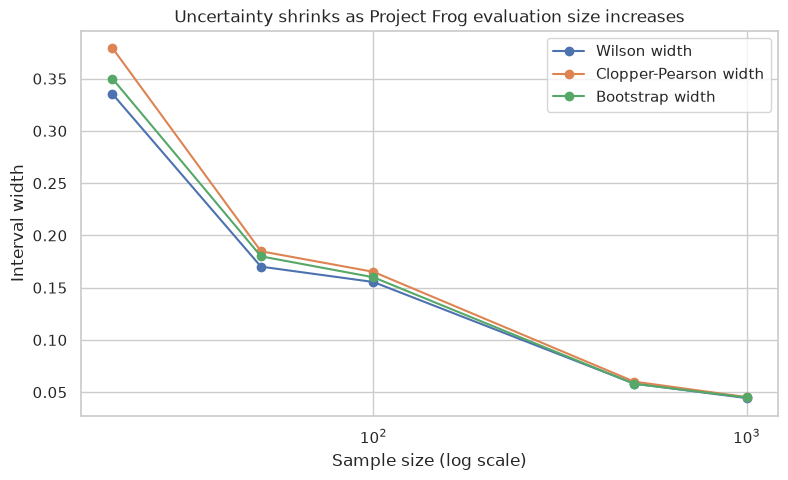

In [5]:
plot_df = summary.merge(bootstrap_summary, on="sample_size")
plot_df["wilson_width"] = plot_df["wilson_upper"] - plot_df["wilson_lower"]
plot_df["exact_width"] = plot_df["exact_upper"] - plot_df["exact_lower"]
plot_df["bootstrap_width"] = plot_df["bootstrap_upper"] - plot_df["bootstrap_lower"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(plot_df["sample_size"], plot_df["wilson_width"], marker="o", label="Wilson width")
ax.plot(plot_df["sample_size"], plot_df["exact_width"], marker="o", label="Clopper-Pearson width")
ax.plot(plot_df["sample_size"], plot_df["bootstrap_width"], marker="o", label="Bootstrap width")
ax.set_xscale("log")
ax.set_xlabel("Sample size (log scale)")
ax.set_ylabel("Interval width")
ax.set_title("Uncertainty shrinks as Project Frog evaluation size increases")
ax.legend()
plt.show()

## Sample-size effects and the common misconception

The true generating accuracy remains fixed at 0.85 in every simulation below. Only the **observed variability** changes.

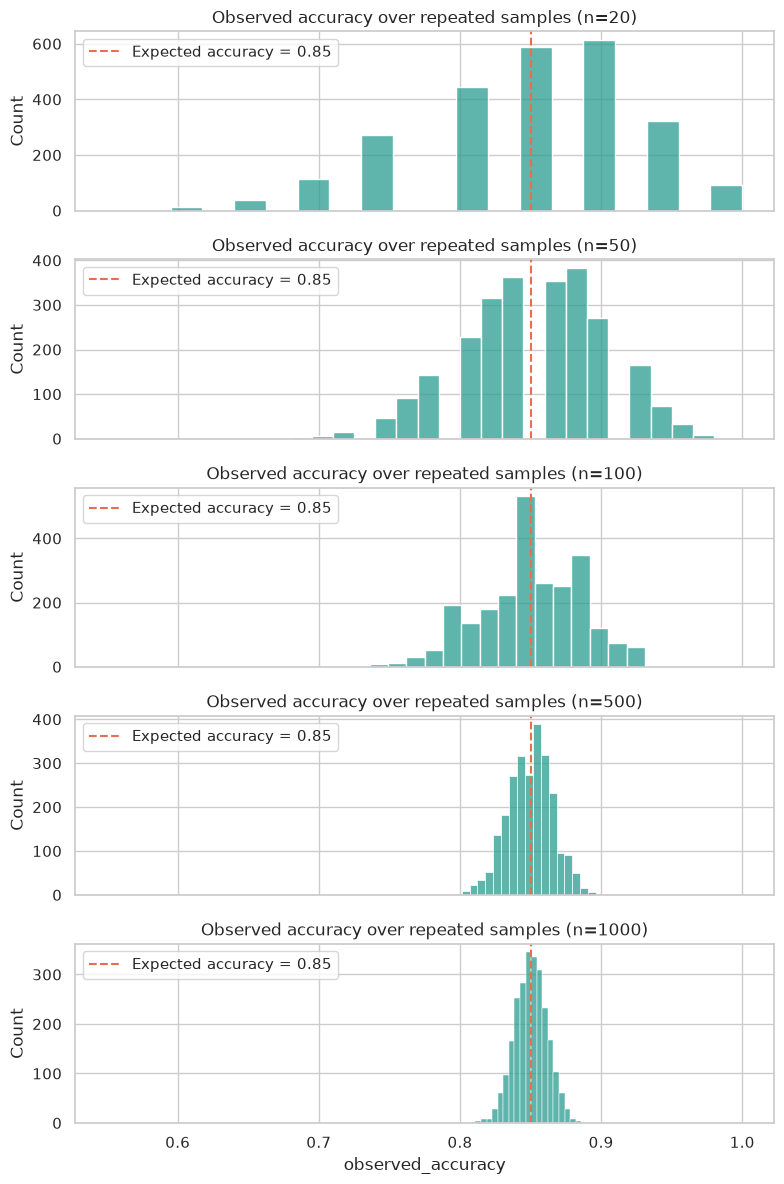

In [6]:
simulation_rows = []
for n in sample_sizes:
    repeated = rng.binomial(n, accuracy, size=2500) / n
    simulation_rows.extend({"sample_size": n, "observed_accuracy": value} for value in repeated)

sim_df = pd.DataFrame(simulation_rows)

fig, axes = plt.subplots(len(sample_sizes), 1, figsize=(8, 12), sharex=True)
for ax, n in zip(axes, sample_sizes):
    subset = sim_df.loc[sim_df["sample_size"] == n, "observed_accuracy"]
    sns.histplot(subset, bins=20, ax=ax, color="#2a9d8f")
    ax.axvline(accuracy, color="#e76f51", linestyle="--", label="Expected accuracy = 0.85")
    ax.set_title(f"Observed accuracy over repeated samples (n={n})")
    ax.legend()
plt.tight_layout()
plt.show()

## Interpretation

- Smaller samples make the estimate noisier and the intervals wider.
- The center of the repeated sampling distribution still stays near 0.85.
- Small samples reduce confidence in the estimate, but they do **not** automatically reduce the true underlying accuracy.
- If Project Frog reports 84% on 75 examples, the next question is not only *"is 84 lower?"* but also *"how uncertain is 84?"*

In [7]:
interval_comparison = pd.DataFrame(
    {
        "sample_size": plot_df["sample_size"],
        "observed_accuracy": plot_df["observed_accuracy"],
        "wilson_interval": list(
            zip(
                plot_df["wilson_lower"].round(4),
                plot_df["wilson_upper"].round(4),
            )
        ),
        "exact_interval": list(
            zip(
                plot_df["exact_lower"].round(4),
                plot_df["exact_upper"].round(4),
            )
        ),
        "bootstrap_interval": list(
            zip(
                plot_df["bootstrap_lower"].round(4),
                plot_df["bootstrap_upper"].round(4),
            )
        ),
    }
)
interval_comparison

,sample_size,observed_accuracy,wilson_interval,exact_interval,bootstrap_interval
0,20,0.800,"(0.584, 0.9193)","(0.5634, 0.9427)","(0.6, 0.95)"
1,50,0.900,"(0.7864, 0.9565)","(0.7819, 0.9667)","(0.8, 0.98)"
2,100,0.800,"(0.7112, 0.8666)","(0.7082, 0.8733)","(0.72, 0.88)"
3,500,0.874,"(0.842, 0.9003)","(0.8417, 0.9018)","(0.844, 0.902)"
4,1000,0.849,"(0.8255, 0.8699)","(0.8253, 0.8706)","(0.826, 0.871)"


## Next questions for an engineer

Once interval estimation is clear, the next engineering questions are:

- Are two releases being compared on the same examples?
- Is the case mix comparable?
- Are observations independent, or clustered by project?
- What additional data would reduce uncertainty enough to change the release decision?